# Prediksjonsintervaller ((5) fra Gudmund)

## Assumptions

We assume that the data are generated from a two-state hidden Markov model with state-dependent AR(1) dynamics. Conditional on the hidden state, the one-step innovation is Gaussian with mean zero and state-specific standard deviation.

For the single AR(1) benchmark, we assume a common linear AR(1) structure across the full sample. For the HMM-based forecasts, we estimate the model on the training sample and produce one-step-ahead predictions on the test sample using either a hard state classification or a probability-weighted mixture of states.

Prediction intervals are constructed under Gaussian assumptions. For the mixture forecast, we use the mean and variance of the implied Gaussian mixture to form an approximate normal prediction interval.


## Imports

In [1]:
import numpy as np
from scipy.stats import norm
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from methods.hmm_ar_1_k_states import fit_model, forward_algorithm, simulate_rs_ar1
import pandas as pd



## Hjelpefunksjoner

In [2]:

def compute_rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def empirical_coverage(y_true, lower, upper):
    y_true = np.asarray(y_true)
    lower = np.asarray(lower)
    upper = np.asarray(upper)
    mask = np.isfinite(y_true) & np.isfinite(lower) & np.isfinite(upper)
    return np.mean((y_true[mask] >= lower[mask]) & (y_true[mask] <= upper[mask]))


def average_interval_width(lower, upper):
    lower = np.asarray(lower)
    upper = np.asarray(upper)
    mask = np.isfinite(lower) & np.isfinite(upper)
    return np.mean(upper[mask] - lower[mask])


def fit_single_ar1(y):
    y = np.asarray(y)
    x = y[:-1]
    z = y[1:]

    rho_hat = np.sum(x * z) / np.sum(x ** 2)
    resid = z - rho_hat * x
    sigma_hat = np.sqrt(np.mean(resid ** 2))

    return rho_hat, sigma_hat

def predict_single_ar1(y_train, y_test, rho_hat, sigma_hat, alpha=0.05):
    y_train = np.asarray(y_train)
    y_test = np.asarray(y_test)

    z_alpha = norm.ppf(1 - alpha / 2)

    pred_mean = np.zeros(len(y_test))
    lower = np.zeros(len(y_test))
    upper = np.zeros(len(y_test))

    prev_y = y_train[-1]

    for t in range(len(y_test)):
        mu = rho_hat * prev_y

        pred_mean[t] = mu
        lower[t] = mu - z_alpha * sigma_hat
        upper[t] = mu + z_alpha * sigma_hat

        prev_y = y_test[t]

    return pred_mean, lower, upper



def fit_hmm_robust(y, K, n_starts=10, seed=123):
    rng = np.random.default_rng(seed)

    best_result = None
    best_params = None
    best_loglik = -np.inf

    for _ in range(n_starts):
        beta0 = rng.normal(0.0, 0.5, size=K)
        sigma0 = rng.normal(0.0, 0.3, size=K)
        P0 = rng.normal(0.0, 0.5, size=(K, K))

        try:
            result, params_hat = fit_model(y, beta0, sigma0, P0)
            loglik = -result.fun

            if result.success and np.isfinite(loglik) and loglik > best_loglik:
                best_result = result
                best_params = params_hat
                best_loglik = loglik
        except Exception:
            pass

    if best_params is None:
        raise RuntimeError("HMM fit failed for all random starts.")

    return best_result, best_params


def get_filtered_probs(y, params_hat):
    alpha, c, loglik = forward_algorithm(
        y=np.asarray(y),
        beta=np.asarray(params_hat["beta"]),
        sigma=np.asarray(params_hat["sigma"]),
        P=np.asarray(params_hat["P"]),
        pi=None,
    )
    return alpha


def predict_hmm_hard(y_train, y_test, params_hat, alpha=0.05):
    y_train = np.asarray(y_train)
    y_test = np.asarray(y_test)

    beta = np.asarray(params_hat["beta"])
    sigma = np.asarray(params_hat["sigma"])
    P = np.asarray(params_hat["P"])

    z_alpha = norm.ppf(1 - alpha / 2)

    filtered_train = get_filtered_probs(y_train, params_hat)
    state_probs_t = filtered_train[-1]

    pred_mean = np.zeros(len(y_test))
    lower = np.zeros(len(y_test))
    upper = np.zeros(len(y_test))

    prev_y = y_train[-1]

    for t in range(len(y_test)):
        state_probs_next = state_probs_t @ P
        k = np.argmax(state_probs_next)

        mu = beta[k] * prev_y
        sd = sigma[k]

        pred_mean[t] = mu
        lower[t] = mu - z_alpha * sd
        upper[t] = mu + z_alpha * sd

        y_obs = y_test[t]
        emission = np.array([
            norm.pdf(y_obs, loc=beta[j] * prev_y, scale=sigma[j])
            for j in range(len(beta))
        ])

        numer = state_probs_next * emission
        denom = numer.sum()

        if denom > 0 and np.isfinite(denom):
            state_probs_t = numer / denom
        else:
            state_probs_t = state_probs_next / state_probs_next.sum()

        prev_y = y_obs

    return pred_mean, lower, upper


def predict_hmm_mixture(y_train, y_test, params_hat, alpha=0.05):
    y_train = np.asarray(y_train)
    y_test = np.asarray(y_test)

    beta = np.asarray(params_hat["beta"])
    sigma = np.asarray(params_hat["sigma"])
    P = np.asarray(params_hat["P"])

    z_alpha = norm.ppf(1 - alpha / 2)

    filtered_train = get_filtered_probs(y_train, params_hat)
    state_probs_t = filtered_train[-1]

    pred_mean = np.zeros(len(y_test))
    lower = np.zeros(len(y_test))
    upper = np.zeros(len(y_test))

    prev_y = y_train[-1]

    for t in range(len(y_test)):
        w = state_probs_t @ P
        means = beta * prev_y

        mix_mean = np.sum(w * means)
        mix_var = np.sum(w * (sigma**2 + means**2)) - mix_mean**2
        mix_sd = np.sqrt(max(mix_var, 0.0))

        pred_mean[t] = mix_mean
        lower[t] = mix_mean - z_alpha * mix_sd
        upper[t] = mix_mean + z_alpha * mix_sd

        y_obs = y_test[t]
        emission = np.array([
            norm.pdf(y_obs, loc=beta[j] * prev_y, scale=sigma[j])
            for j in range(len(beta))
        ])

        numer = w * emission
        denom = numer.sum()

        if denom > 0 and np.isfinite(denom):
            state_probs_t = numer / denom
        else:
            state_probs_t = w / w.sum()

        prev_y = y_obs

    return pred_mean, lower, upper


def evaluate_predictions(y_true, pred_mean, lower, upper):
    return {
        "rmse": compute_rmse(y_true, pred_mean),
        "coverage": empirical_coverage(y_true, lower, upper),
        "avg_width": average_interval_width(lower, upper),
    }


## Simulering

In [3]:
T = 1000
beta_true = np.array([0.2, 0.7])
sigma_true = np.array([0.5, 1.5])
p_stay = 0.95

P_true = np.array([
    [p_stay, 1 - p_stay],
    [1 - p_stay, p_stay]
])

y, states = simulate_rs_ar1(
    T=T,
    beta=beta_true,
    sigma=sigma_true,
    P=P_true,
    seed=123
)

# Train/test split
train_frac = 0.8
split = int(train_frac * T)

y_train = y[:split]
y_test = y[split:]

states_train = states[:split]
states_test = states[split:]


## Estimate AR(1)

In [4]:
rho_hat, sigma_hat = fit_single_ar1(y_train)

## Estimate HMM

In [5]:
seed = 270401
_, params_hat = fit_hmm_robust(y_train, K=2, n_starts=10, seed=seed)

## Prediction Interval AR(1)

In [6]:
pred_mean_ar1, lower_ar1, upper_ar1 = predict_single_ar1(
    y_train=y_train,
    y_test=y_test,
    rho_hat=rho_hat,
    sigma_hat=sigma_hat,
    alpha=0.05
)

ar1_results = evaluate_predictions(
    y_true=y_test,
    pred_mean=pred_mean_ar1,
    lower=lower_ar1,
    upper=upper_ar1
)


print(ar1_results)


pd.DataFrame({
    "y_true": y_test,
    "pred_mean": pred_mean_ar1,
    "lower_95": lower_ar1,
    "upper_95": upper_ar1
}).head()



{'rmse': 1.1914605915335792, 'coverage': 0.93, 'avg_width': 4.767055066535823}


,y_true,pred_mean,lower_95,upper_95
0,0.263551,1.123703,-1.259824,3.507231
1,1.223082,0.179158,-2.204369,2.562686
2,0.051834,0.831434,-1.552093,3.214962
3,2.713183,0.035236,-2.348292,2.418763
4,0.459034,1.844384,-0.539143,4.227912


## Prediction Interval HMM hard switch

In [7]:
pred_mean_hard, lower_hard, upper_hard = predict_hmm_hard(
    y_train=y_train,
    y_test=y_test,
    params_hat=params_hat,
    alpha=0.05
)

hard_results = evaluate_predictions(
    y_true=y_test,
    pred_mean=pred_mean_hard,
    lower=lower_hard,
    upper=upper_hard
)


print(hard_results)

hard_df = pd.DataFrame({
    "y_true": y_test,
    "pred_mean": pred_mean_hard,
    "lower_95": lower_hard,
    "upper_95": upper_hard
})

hard_df.head()



{'rmse': 1.1904578982427636, 'coverage': 0.93, 'avg_width': 4.2680283666901495}


,y_true,pred_mean,lower_95,upper_95
0,0.263551,1.182931,-1.633914,3.999776
1,1.223082,0.188602,-2.628244,3.005447
2,0.051834,0.875257,-1.941588,3.692103
3,2.713183,0.037093,-2.779752,2.853938
4,0.459034,1.941598,-0.875247,4.758443


## Prediction Interval HMM mixture

In [8]:
pred_mean_mix, lower_mix, upper_mix = predict_hmm_mixture(
    y_train=y_train,
    y_test=y_test,
    params_hat=params_hat,
    alpha=0.05
)

mix_results = evaluate_predictions(
    y_true=y_test,
    pred_mean=pred_mean_mix,
    lower=lower_mix,
    upper=upper_mix
)


print(mix_results)

mix_df = pd.DataFrame({
    "y_true": y_test,
    "pred_mean": pred_mean_mix,
    "lower_95": lower_mix,
    "upper_95": upper_mix
})

mix_df.head()




{'rmse': 1.191595170742129, 'coverage': 0.945, 'avg_width': 4.5093055647427835}


,y_true,pred_mean,lower_95,upper_95
0,0.263551,1.134544,-1.636889,3.905976
1,1.223082,0.160947,-2.388870,2.710764
2,0.051834,0.823490,-1.909067,3.556047
3,2.713183,0.030590,-2.460967,2.522146
4,0.459034,1.879641,-0.937801,4.697082


## Tester kjøretid for rolling window

In [9]:
# import time
# import numpy as np
# import pandas as pd
# from scipy.stats import norm

# # Rolling / re-fitting evaluation for HMM hard switch
# # Assumes the following are already available in the notebook:
# # - fit_hmm_robust
# # - compute_rmse
# # - empirical_coverage
# # - average_interval_width
# # - y_train
# # - y_test

# start_time = time.time()

# alpha_level = 0.05
# z_alpha = norm.ppf(1 - alpha_level / 2)
# K = 2
# n_starts = 10
# seed_base = 270401

# pred_mean_hard_roll = np.zeros(len(y_test))
# lower_hard_roll = np.zeros(len(y_test))
# upper_hard_roll = np.zeros(len(y_test))

# y_history = np.array(y_train, copy=True)

# for t in range(len(y_test)):
#     # Re-fit HMM on all data observed so far
#     _, params_hat_roll = fit_hmm_robust(
#         y=y_history,
#         K=K,
#         n_starts=n_starts,
#         seed=seed_base + t
#     )

#     beta = np.asarray(params_hat_roll["beta"])
#     sigma = np.asarray(params_hat_roll["sigma"])
#     P = np.asarray(params_hat_roll["P"])

#     # Filter on current history to get latest state probabilities
#     filtered_hist = get_filtered_probs(y_history, params_hat_roll)
#     state_probs_t = filtered_hist[-1]

#     # One-step-ahead prediction for next observation
#     state_probs_next = state_probs_t @ P
#     k = np.argmax(state_probs_next)

#     prev_y = y_history[-1]
#     mu = beta[k] * prev_y
#     sd = sigma[k]

#     pred_mean_hard_roll[t] = mu
#     lower_hard_roll[t] = mu - z_alpha * sd
#     upper_hard_roll[t] = mu + z_alpha * sd

#     # Add realized observation to history before next step
#     y_history = np.append(y_history, y_test[t])

# elapsed_time = time.time() - start_time

# hard_roll_results = {
#     "rmse": compute_rmse(y_test, pred_mean_hard_roll),
#     "coverage": empirical_coverage(y_test, lower_hard_roll, upper_hard_roll),
#     "avg_width": average_interval_width(lower_hard_roll, upper_hard_roll),
#     "runtime_seconds": elapsed_time,
# }

# print(hard_roll_results)

# hard_roll_df = pd.DataFrame({
#     "y_true": y_test,
#     "pred_mean": pred_mean_hard_roll,
#     "lower_95": lower_hard_roll,
#     "upper_95": upper_hard_roll,
# })

# hard_roll_df["covered"] = (
#     (hard_roll_df["y_true"] >= hard_roll_df["lower_95"]) &
#     (hard_roll_df["y_true"] <= hard_roll_df["upper_95"])
# )

# hard_roll_df.head()


## Hva påvirker?

In [10]:
results = []

T_vals = [200, 500, 1000, 1500, 2000]
diff_vals = [0.1, 0.3, 0.5, 0.7]
p_stay_vals = [0.6, 0.8, 0.95, 0.98]
n_rep = 20

train_frac = 0.8
alpha_level = 0.05
sigma_true = np.array([0.5, 1.5])

for T in T_vals:
    for diff in diff_vals:
        beta_true = np.array([0.2, 0.2 + diff])

        for p_stay in p_stay_vals:
            P_true = np.array([
                [p_stay, 1 - p_stay],
                [1 - p_stay, p_stay]
            ])

            for rep in range(n_rep):
                seed = 1000 * rep + int(100 * p_stay) + int(1000 * diff) + T

                try:
                    y, states = simulate_rs_ar1(
                        T=T,
                        beta=beta_true,
                        sigma=sigma_true,
                        P=P_true,
                        seed=seed
                    )

                    split = int(train_frac * T)
                    y_train = y[:split]
                    y_test = y[split:]

                    # Single AR(1)
                    rho_hat, sigma_hat = fit_single_ar1(y_train)
                    pred_mean_ar1, lower_ar1, upper_ar1 = predict_single_ar1(
                        y_train=y_train,
                        y_test=y_test,
                        rho_hat=rho_hat,
                        sigma_hat=sigma_hat,
                        alpha=alpha_level
                    )
                    ar1_eval = evaluate_predictions(
                        y_true=y_test,
                        pred_mean=pred_mean_ar1,
                        lower=lower_ar1,
                        upper=upper_ar1
                    )

                    # HMM
                    _, params_hat = fit_hmm_robust(
                        y=y_train,
                        K=2,
                        n_starts=10,
                        seed=seed
                    )

                    pred_mean_hard, lower_hard, upper_hard = predict_hmm_hard(
                        y_train=y_train,
                        y_test=y_test,
                        params_hat=params_hat,
                        alpha=alpha_level
                    )
                    hard_eval = evaluate_predictions(
                        y_true=y_test,
                        pred_mean=pred_mean_hard,
                        lower=lower_hard,
                        upper=upper_hard
                    )

                    pred_mean_mix, lower_mix, upper_mix = predict_hmm_mixture(
                        y_train=y_train,
                        y_test=y_test,
                        params_hat=params_hat,
                        alpha=alpha_level
                    )
                    mix_eval = evaluate_predictions(
                        y_true=y_test,
                        pred_mean=pred_mean_mix,
                        lower=lower_mix,
                        upper=upper_mix
                    )

                    results.append({
                        "T": T,
                        "diff": diff,
                        "p_stay": p_stay,
                        "rep": rep,
                        "method": "AR1",
                        **ar1_eval
                    })

                    results.append({
                        "T": T,
                        "diff": diff,
                        "p_stay": p_stay,
                        "rep": rep,
                        "method": "HMM_hard",
                        **hard_eval
                    })

                    results.append({
                        "T": T,
                        "diff": diff,
                        "p_stay": p_stay,
                        "rep": rep,
                        "method": "HMM_mixture",
                        **mix_eval
                    })

                except Exception as e:
                    results.append({
                        "T": T,
                        "diff": diff,
                        "p_stay": p_stay,
                        "rep": rep,
                        "method": "failed",
                        "rmse": np.nan,
                        "coverage": np.nan,
                        "avg_width": np.nan,
                        "error": str(e)
                    })

results_df = pd.DataFrame(results)
results_df.head()


/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:86: RuntimeWarning: overflow encountered in exp
  beta = (1-np.exp(-beta_raw)) / (1 + np.exp(-beta_raw))
/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:86: RuntimeWarning: invalid value encountered in divide
  beta = (1-np.exp(-beta_raw)) / (1 + np.exp(-beta_raw))
/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:94: RuntimeWarning: overflow encountered in exp
  row = np.exp(P_raw[i])
/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:95: RuntimeWarning: invalid value encountered in divide
  P[i] = row / np.sum(row)
/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:89: RuntimeWarning: overflow encountered in exp
  sigma = np.exp(sigma_raw)


,T,diff,p_stay,rep,method,rmse,coverage,avg_width
0,200,0.1,0.6,0,AR1,1.168073,0.925,4.956920
1,200,0.1,0.6,0,HMM_hard,1.150487,0.825,2.337836
2,200,0.1,0.6,0,HMM_mixture,1.167601,0.925,4.930727
3,200,0.1,0.6,1,AR1,0.905011,0.950,4.344209
4,200,0.1,0.6,1,HMM_hard,0.901140,0.850,2.042135


In [11]:
summary_df = (
    results_df[results_df["method"] != "failed"]
    .groupby(["T", "diff", "p_stay", "method"], as_index=False)
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_sd=("rmse", "std"),
        coverage_mean=("coverage", "mean"),
        coverage_sd=("coverage", "std"),
        avg_width_mean=("avg_width", "mean"),
        avg_width_sd=("avg_width", "std"),
        n_runs=("rmse", "count")
    )
)

summary_df


,T,diff,p_stay,method,rmse_mean,rmse_sd,coverage_mean,coverage_sd,avg_width_mean,avg_width_sd,n_runs
0,200,0.1,0.60,AR1,1.144370,0.189760,0.905000,0.048395,4.215402,0.329518,20
1,200,0.1,0.60,HMM_hard,1.145282,0.187626,0.831250,0.085792,3.613295,1.151053,20
2,200,0.1,0.60,HMM_mixture,1.144696,0.190303,0.906250,0.048582,4.197191,0.310681,20
3,200,0.1,0.80,AR1,1.087556,0.262408,0.927500,0.053742,4.330376,0.440233,20
4,200,0.1,0.80,HMM_hard,1.090682,0.273122,0.872500,0.057868,3.778240,1.054133,20
...,...,...,...,...,...,...,...,...,...,...,...
235,2000,0.7,0.95,HMM_hard,1.191660,0.096432,0.910000,0.016182,3.940881,0.354022,20
236,2000,0.7,0.95,HMM_mixture,1.185156,0.097345,0.944375,0.009661,4.422982,0.288588,20
237,2000,0.7,0.98,AR1,1.194651,0.179905,0.932250,0.027240,4.636840,0.241957,20
238,2000,0.7,0.98,HMM_hard,1.175808,0.189916,0.929125,0.014696,4.094332,0.763668,20


### Plott avhenginghet av antall datapunkter, stickyness og diff i parametre

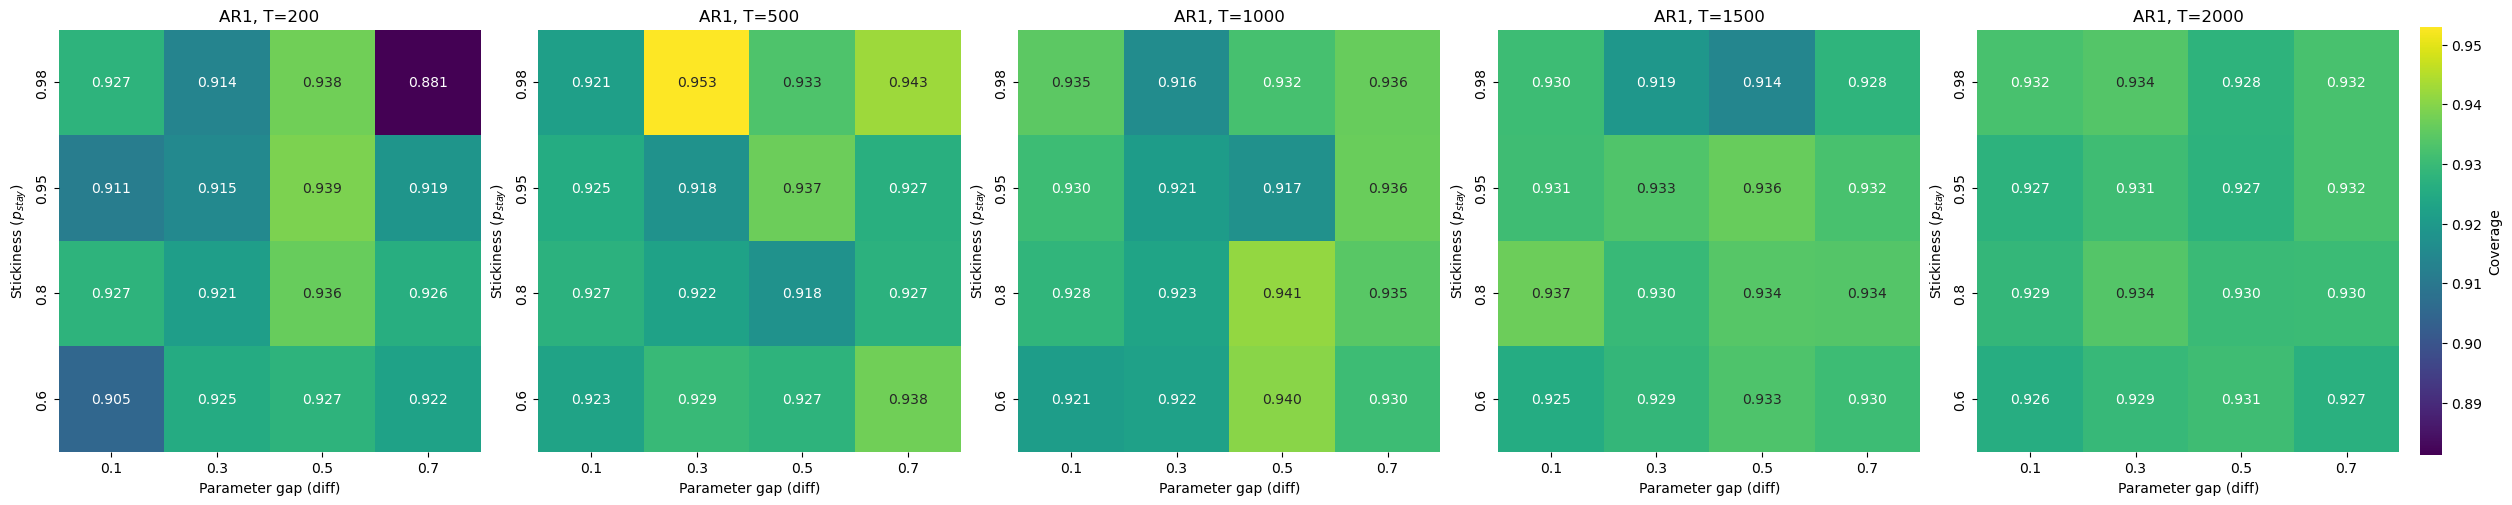

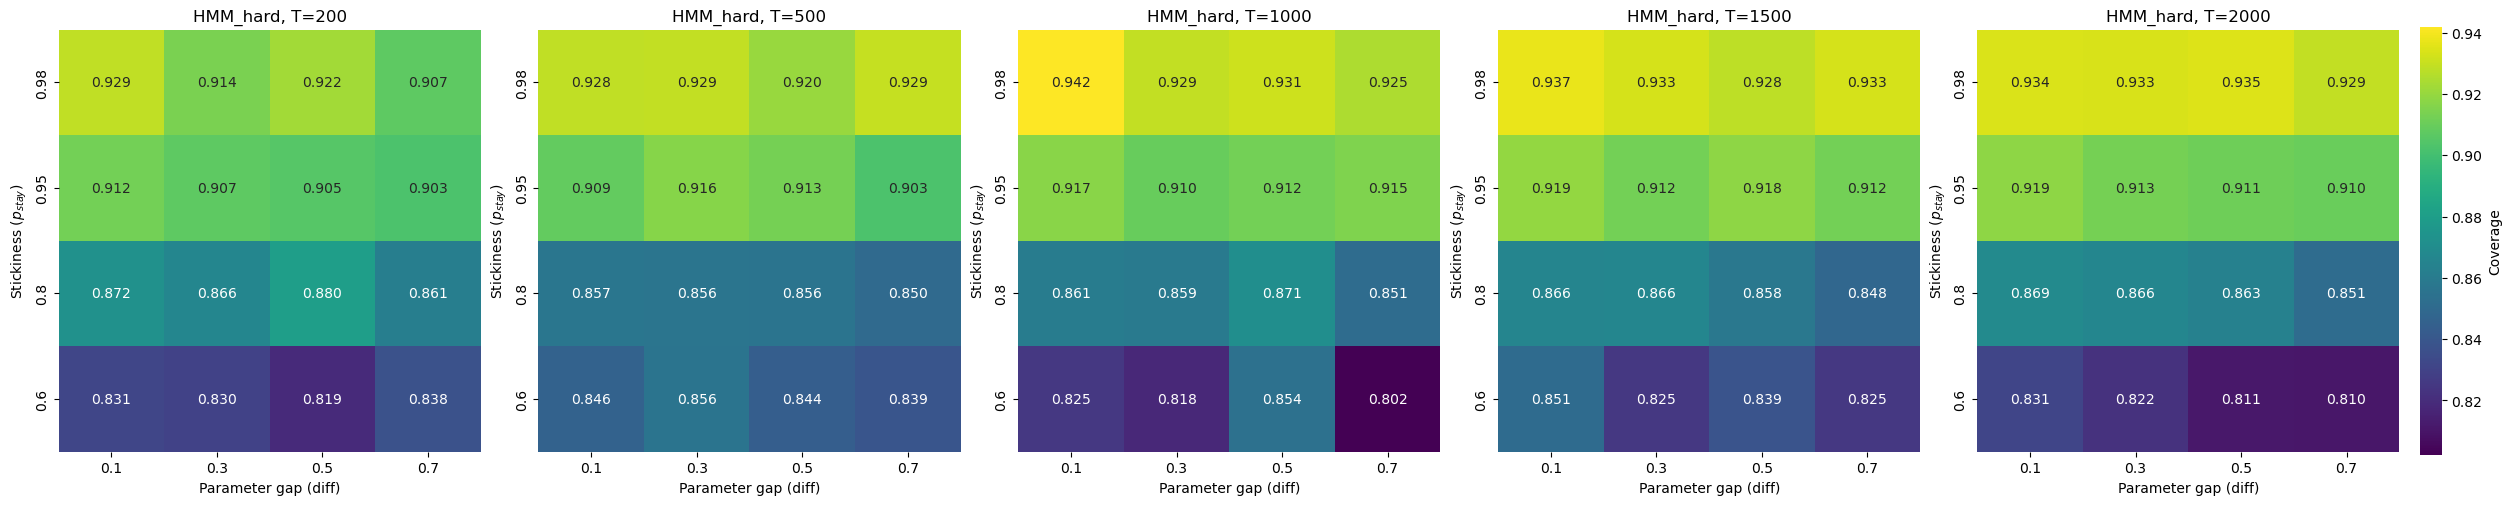

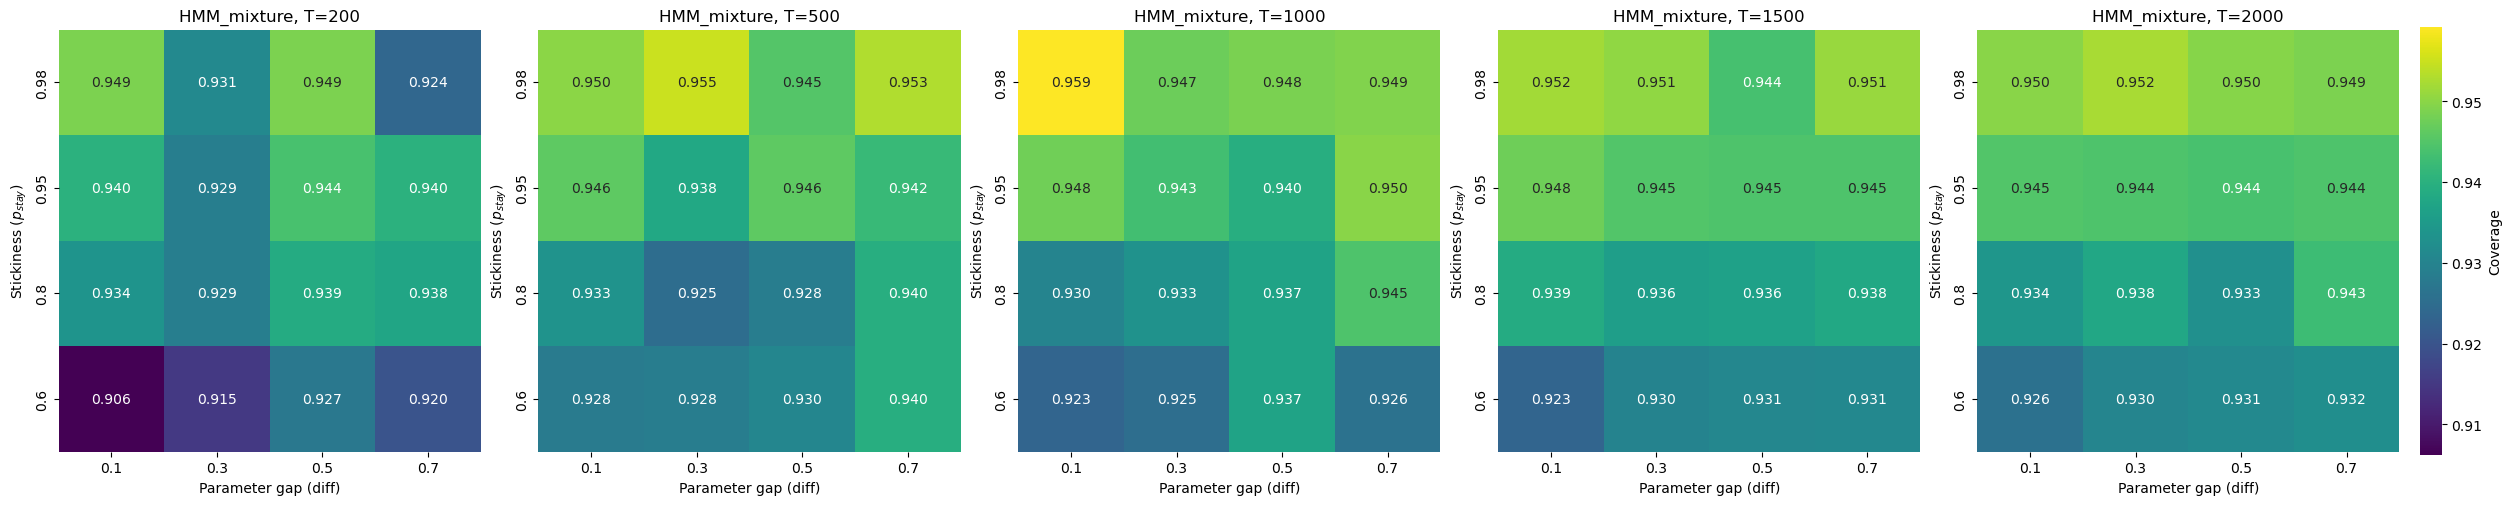

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

methods = ["AR1", "HMM_hard", "HMM_mixture"]

for method in methods:
    plot_df = summary_df[summary_df["method"] == method]

    T_vals_sorted = sorted(plot_df["T"].unique())
    n_panels = len(T_vals_sorted)

    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5), constrained_layout=True)

    if n_panels == 1:
        axes = [axes]

    vmin = plot_df["coverage_mean"].min()
    vmax = plot_df["coverage_mean"].max()

    for ax, T in zip(axes, T_vals_sorted):
        sub = plot_df[plot_df["T"] == T].pivot(
            index="p_stay",
            columns="diff",
            values="coverage_mean"
        ).sort_index(ascending=False)

        sns.heatmap(
            sub,
            ax=ax,
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt=".3f",
            square=True,
            cbar=ax is axes[-1],
            cbar_kws={"label": "Coverage"} if ax is axes[-1] else None
        )

        ax.set_title(f"{method}, T={T}")
        ax.set_xlabel("Parameter gap (diff)")
        ax.set_ylabel("Stickiness ($p_{stay}$)")

    plt.show()


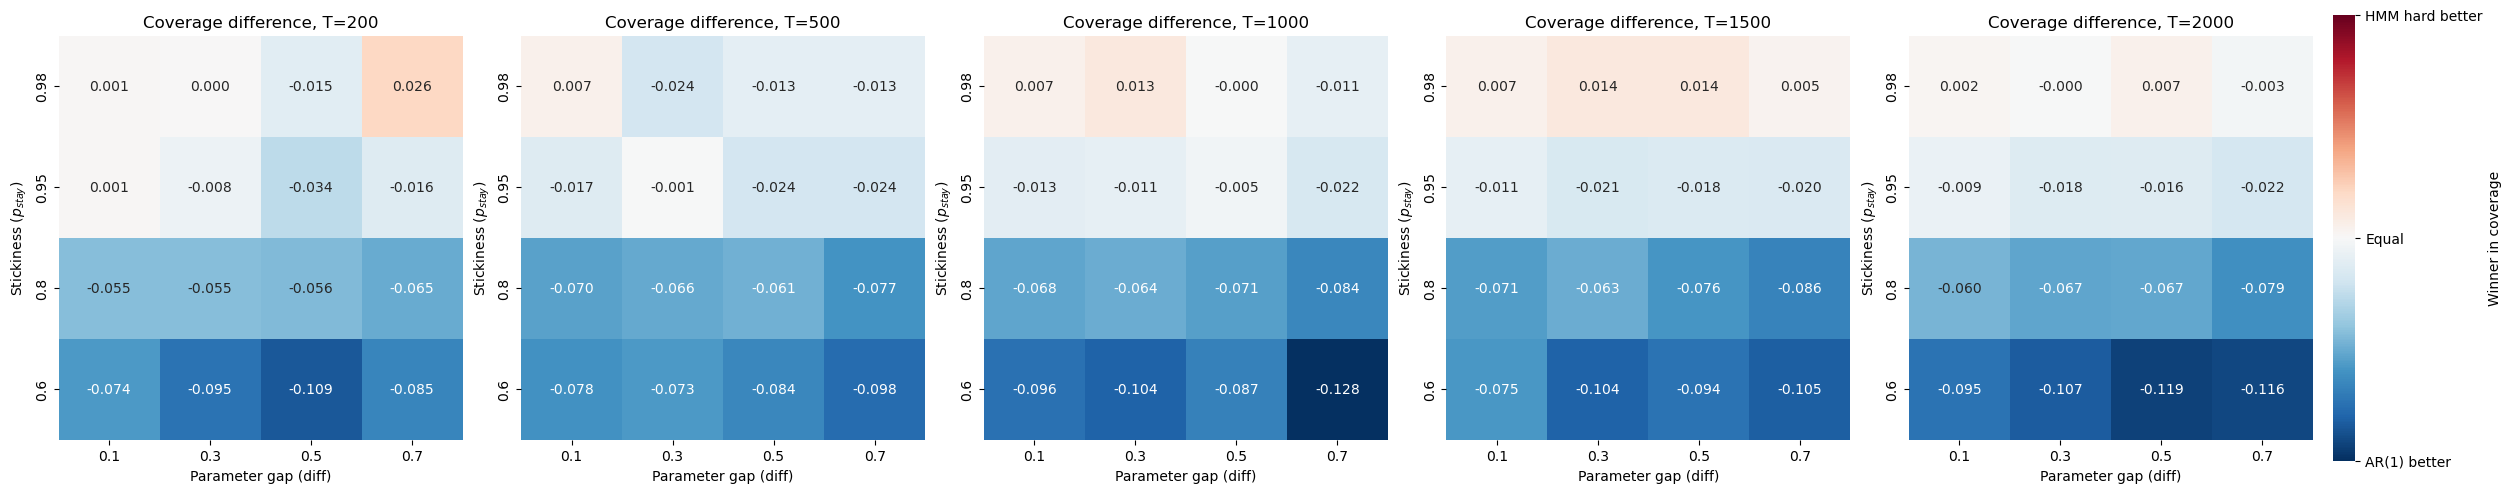

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

ar1_df = summary_df[summary_df["method"] == "AR1"][
    ["T", "diff", "p_stay", "coverage_mean"]
].rename(columns={"coverage_mean": "coverage_ar1"})

hard_df = summary_df[summary_df["method"] == "HMM_hard"][
    ["T", "diff", "p_stay", "coverage_mean"]
].rename(columns={"coverage_mean": "coverage_hard"})

plot_df = hard_df.merge(ar1_df, on=["T", "diff", "p_stay"])
plot_df["coverage_diff"] = plot_df["coverage_hard"] - plot_df["coverage_ar1"]

T_vals_sorted = sorted(plot_df["T"].unique())
n_panels = len(T_vals_sorted)

fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5), constrained_layout=True)

if n_panels == 1:
    axes = [axes]

max_abs = np.nanmax(np.abs(plot_df["coverage_diff"]))

for ax, T in zip(axes, T_vals_sorted):
    sub = plot_df[plot_df["T"] == T].pivot(
        index="p_stay",
        columns="diff",
        values="coverage_diff"
    ).sort_index(ascending=False)

    hm = sns.heatmap(
        sub,
        ax=ax,
        cmap="RdBu_r",
        vmin=-max_abs,
        vmax=max_abs,
        center=0,
        annot=True,
        fmt=".3f",
        square=True,
        cbar=ax is axes[-1],
        cbar_kws={"label": "Winner in coverage"} if ax is axes[-1] else None
    )

    ax.set_title(f"Coverage difference, T={T}")
    ax.set_xlabel("Parameter gap (diff)")
    ax.set_ylabel("Stickiness ($p_{stay}$)")

    if ax is axes[-1]:
        cbar = hm.collections[0].colorbar
        cbar.set_ticks([-max_abs, 0, max_abs])
        cbar.set_ticklabels(["AR(1) better", "Equal", "HMM hard better"])

plt.show()


### Test for å få HMM til å "vinne"

In [14]:
import numpy as np
import pandas as pd

# Scenario where we expect HMM to have a real advantage
T = 2000
beta_true = np.array([0.1, 0.9])
sigma_true = np.array([0.4, 1.8])
p_stay = 0.98

P_true = np.array([
    [p_stay, 1 - p_stay],
    [1 - p_stay, p_stay]
])

seed = 123
train_frac = 0.8
alpha_level = 0.05

# Simulate data
y, states = simulate_rs_ar1(
    T=T,
    beta=beta_true,
    sigma=sigma_true,
    P=P_true,
    seed=seed
)

split = int(train_frac * T)
y_train = y[:split]
y_test = y[split:]

# Fit single AR(1)
rho_hat, sigma_hat = fit_single_ar1(y_train)

# IMPORTANT:
# This assumes you have updated predict_single_ar1 so it takes
# (y_train, y_test, rho_hat, sigma_hat, alpha)
pred_mean_ar1, lower_ar1, upper_ar1 = predict_single_ar1(
    y_train=y_train,
    y_test=y_test,
    rho_hat=rho_hat,
    sigma_hat=sigma_hat,
    alpha=alpha_level
)

ar1_results = evaluate_predictions(
    y_true=y_test,
    pred_mean=pred_mean_ar1,
    lower=lower_ar1,
    upper=upper_ar1
)

ar1_df = pd.DataFrame({
    "y_true": y_test,
    "pred_mean": pred_mean_ar1,
    "lower_95": lower_ar1,
    "upper_95": upper_ar1
})

ar1_df["covered"] = (
    (ar1_df["y_true"] >= ar1_df["lower_95"]) &
    (ar1_df["y_true"] <= ar1_df["upper_95"])
)

# Fit HMM
_, params_hat = fit_hmm_robust(
    y=y_train,
    K=2,
    n_starts=10,
    seed=seed
)

# HMM hard switch
pred_mean_hard, lower_hard, upper_hard = predict_hmm_hard(
    y_train=y_train,
    y_test=y_test,
    params_hat=params_hat,
    alpha=alpha_level
)

hard_results = evaluate_predictions(
    y_true=y_test,
    pred_mean=pred_mean_hard,
    lower=lower_hard,
    upper=upper_hard
)

hard_df = pd.DataFrame({
    "y_true": y_test,
    "pred_mean": pred_mean_hard,
    "lower_95": lower_hard,
    "upper_95": upper_hard
})

hard_df["covered"] = (
    (hard_df["y_true"] >= hard_df["lower_95"]) &
    (hard_df["y_true"] <= hard_df["upper_95"])
)

# HMM mixture
pred_mean_mix, lower_mix, upper_mix = predict_hmm_mixture(
    y_train=y_train,
    y_test=y_test,
    params_hat=params_hat,
    alpha=alpha_level
)

mix_results = evaluate_predictions(
    y_true=y_test,
    pred_mean=pred_mean_mix,
    lower=lower_mix,
    upper=upper_mix
)

mix_df = pd.DataFrame({
    "y_true": y_test,
    "pred_mean": pred_mean_mix,
    "lower_95": lower_mix,
    "upper_95": upper_mix
})

mix_df["covered"] = (
    (mix_df["y_true"] >= mix_df["lower_95"]) &
    (mix_df["y_true"] <= mix_df["upper_95"])
)

# Collect comparison table
comparison_df = pd.DataFrame([
    {"method": "AR(1)", **ar1_results},
    {"method": "HMM hard switch", **hard_results},
    {"method": "HMM mixture", **mix_results},
])

comparison_df["coverage_error"] = np.abs(comparison_df["coverage"] - 0.95)

comparison_df


,method,rmse,coverage,avg_width,coverage_error
0,AR(1),1.335737,0.925,5.467610,0.025
1,HMM hard switch,1.316017,0.925,3.675983,0.025
2,HMM mixture,1.310205,0.955,4.111018,0.005


### Masse plots

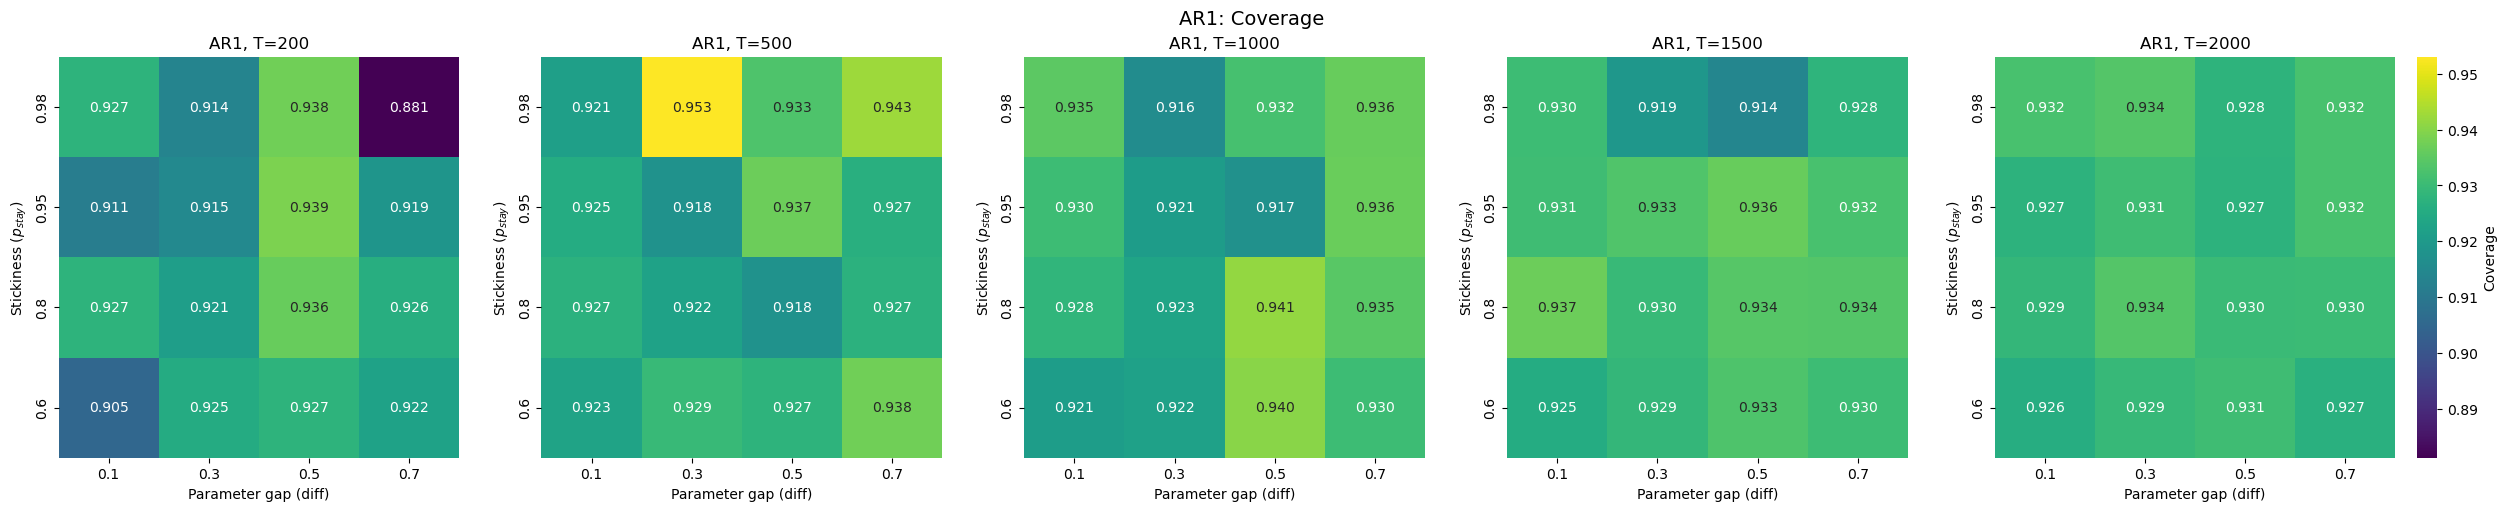

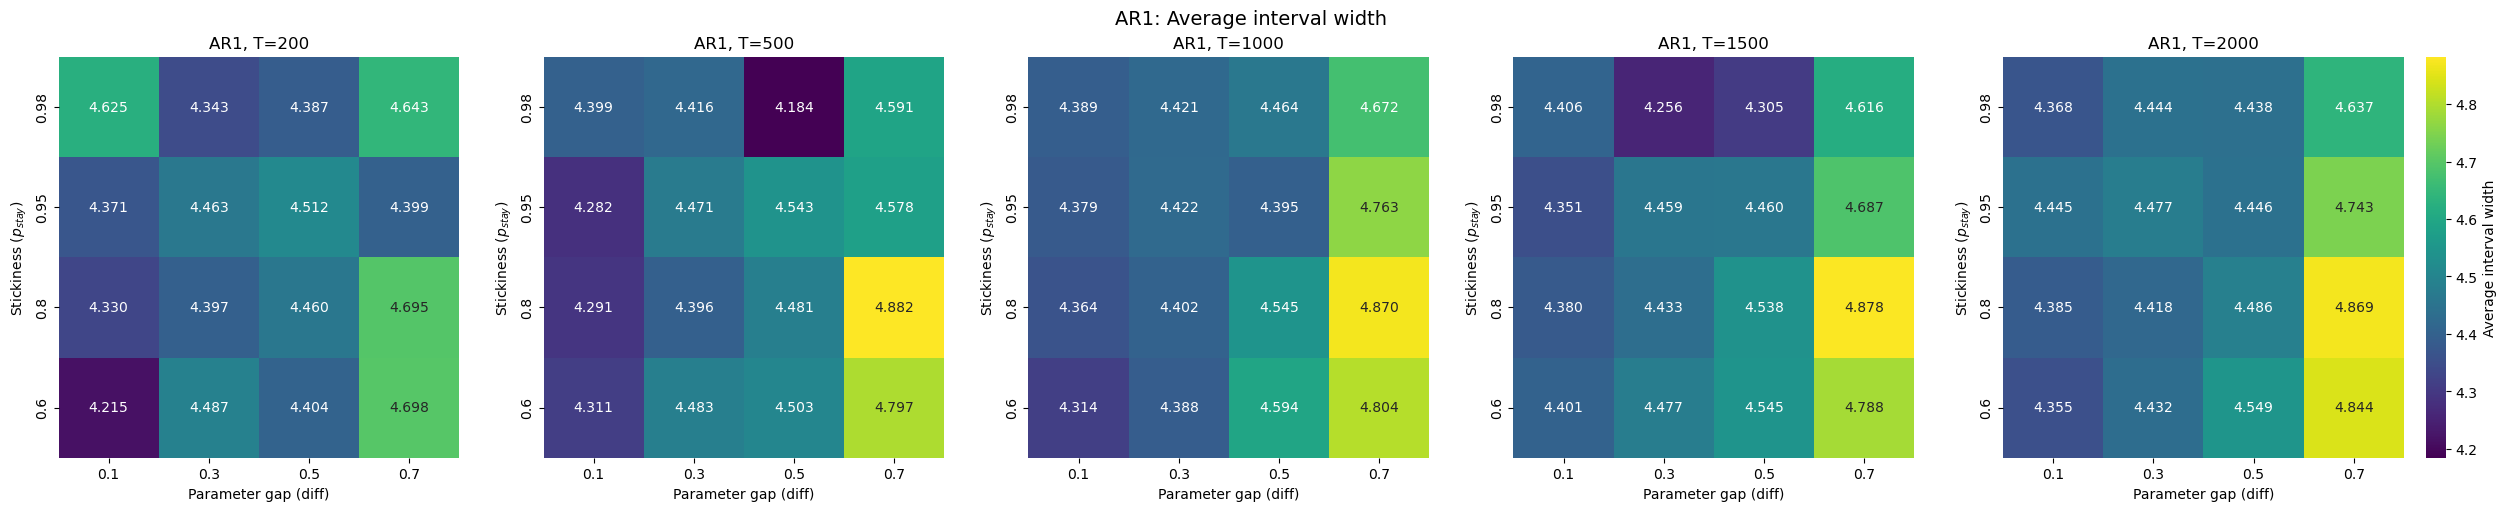

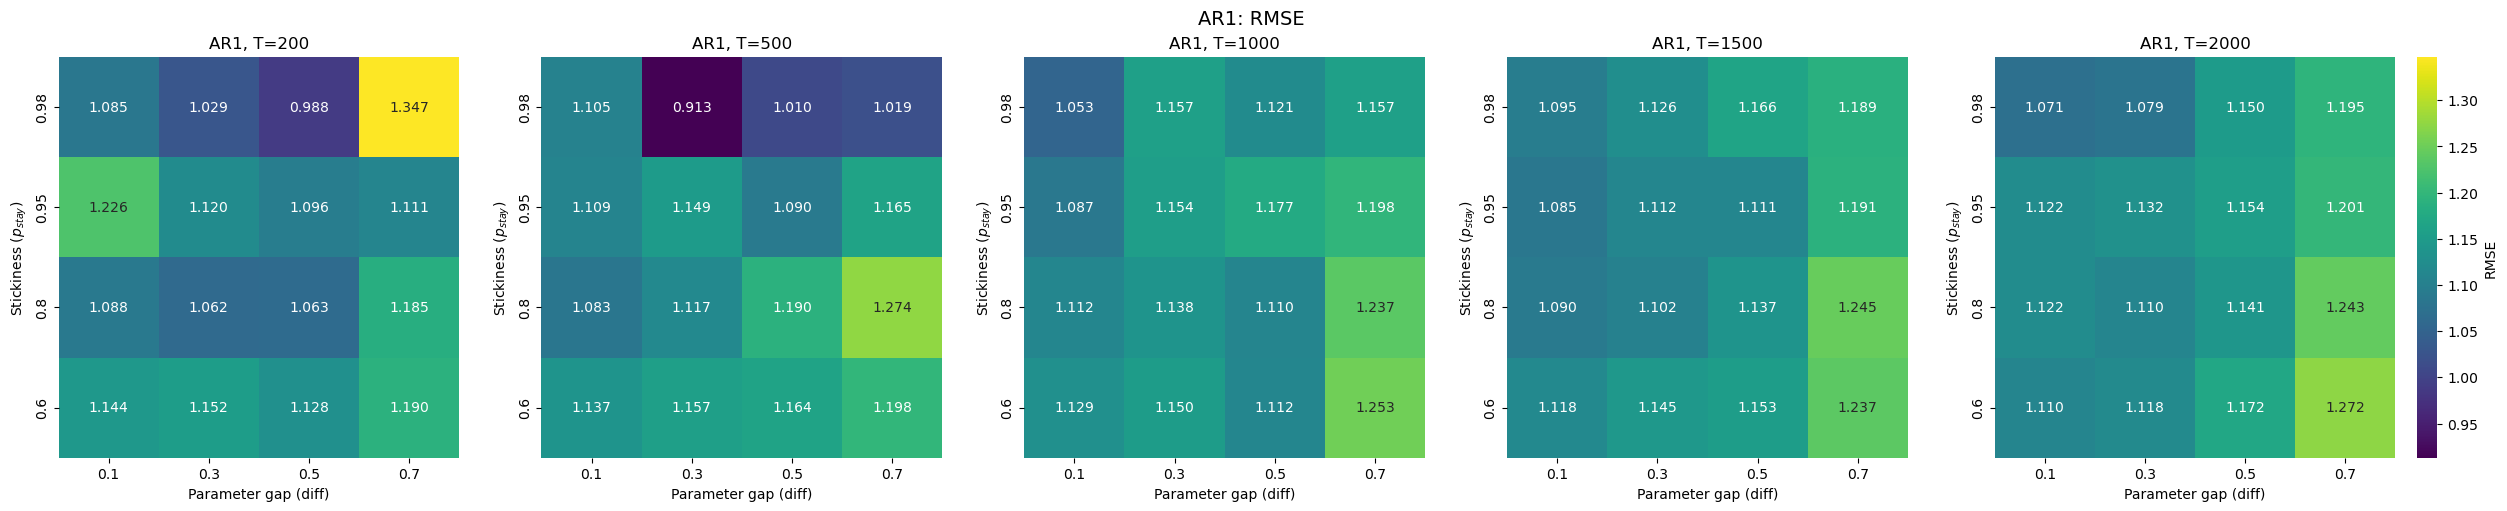

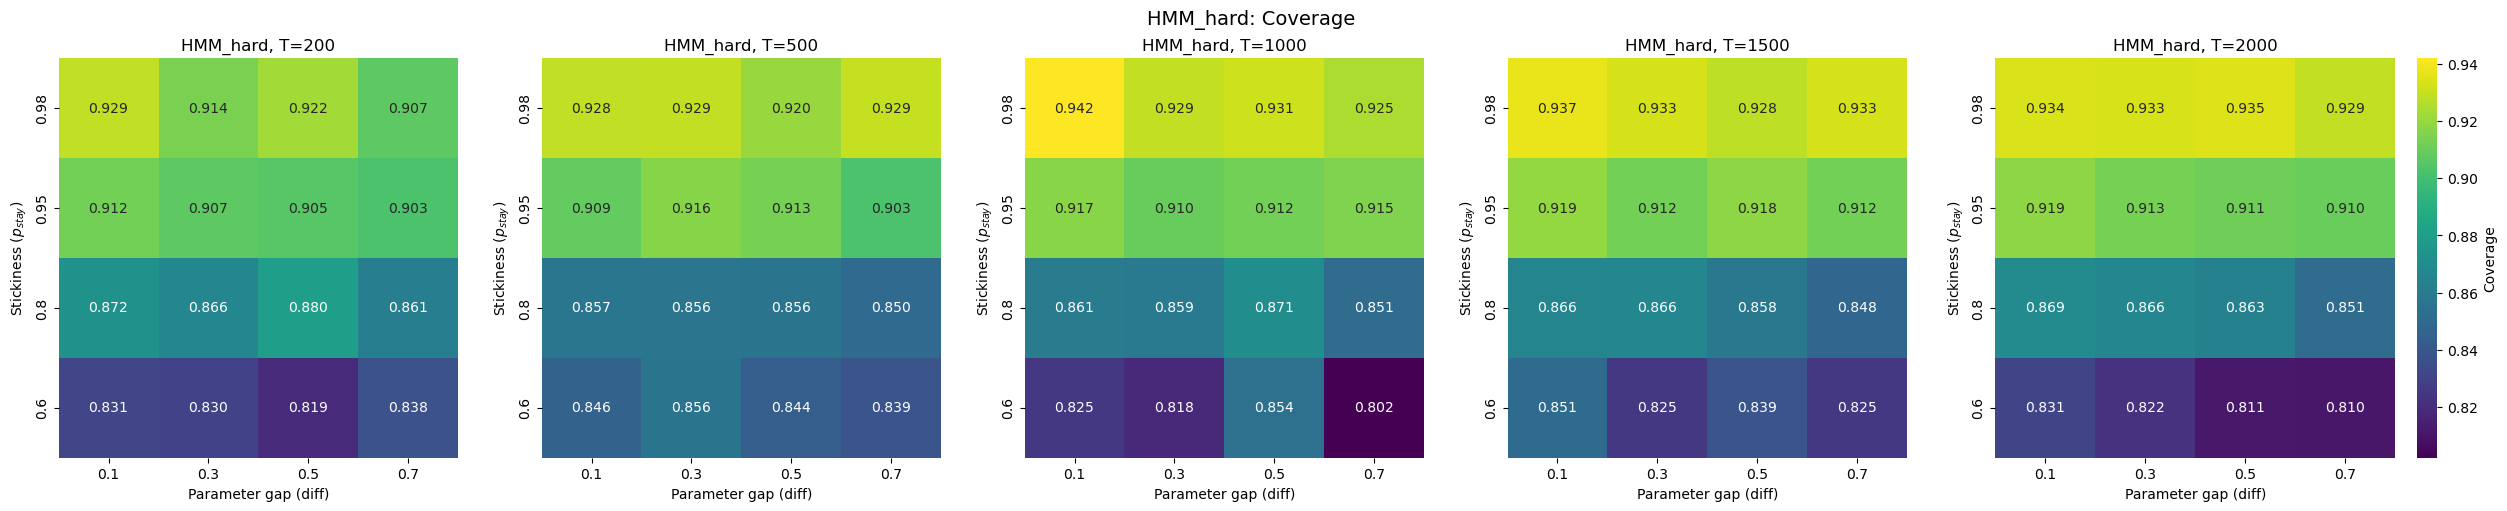

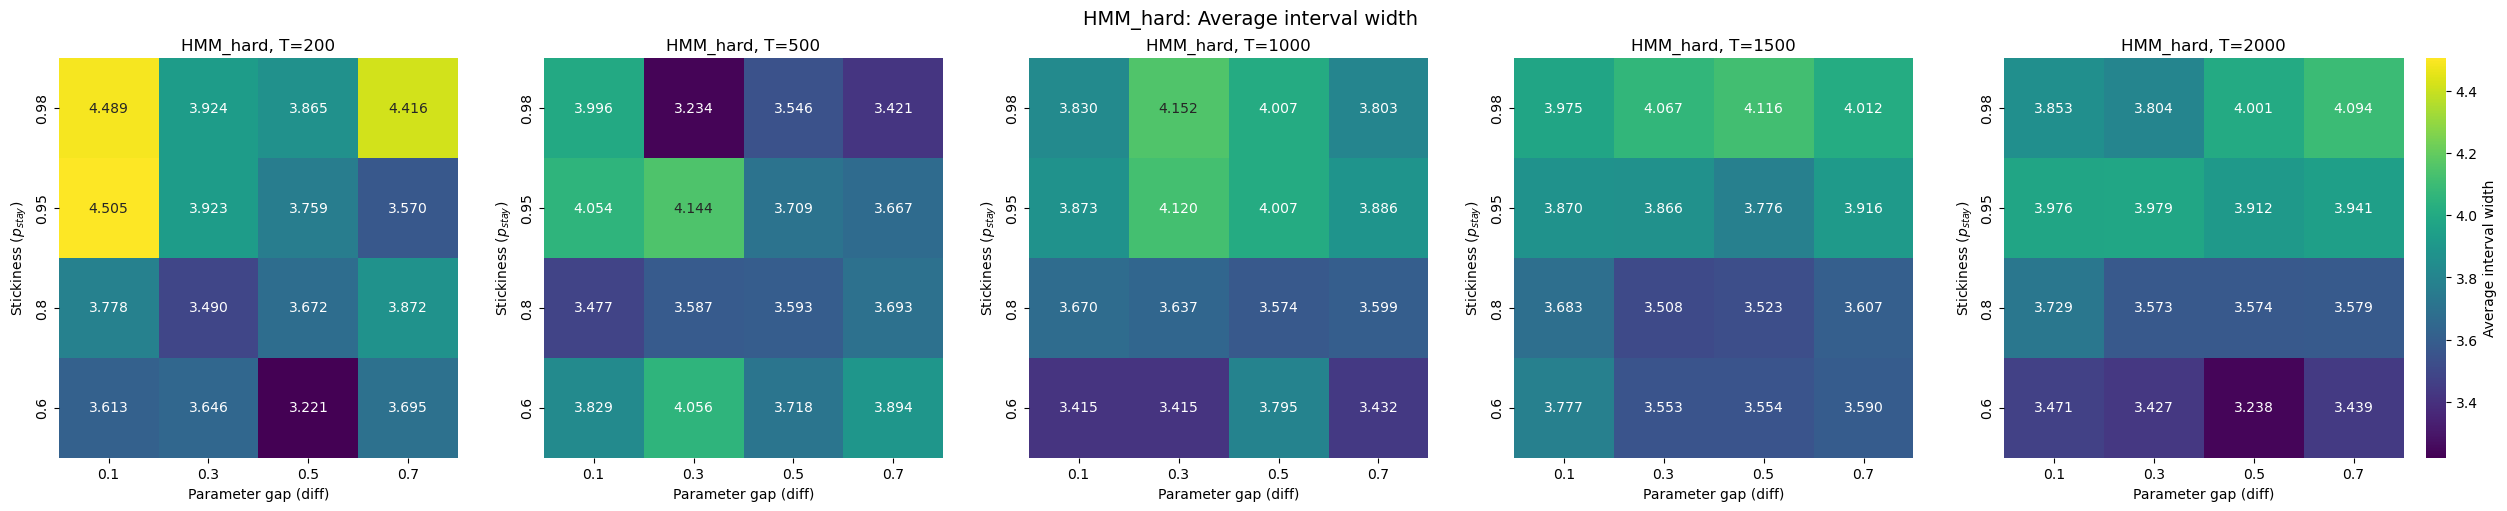

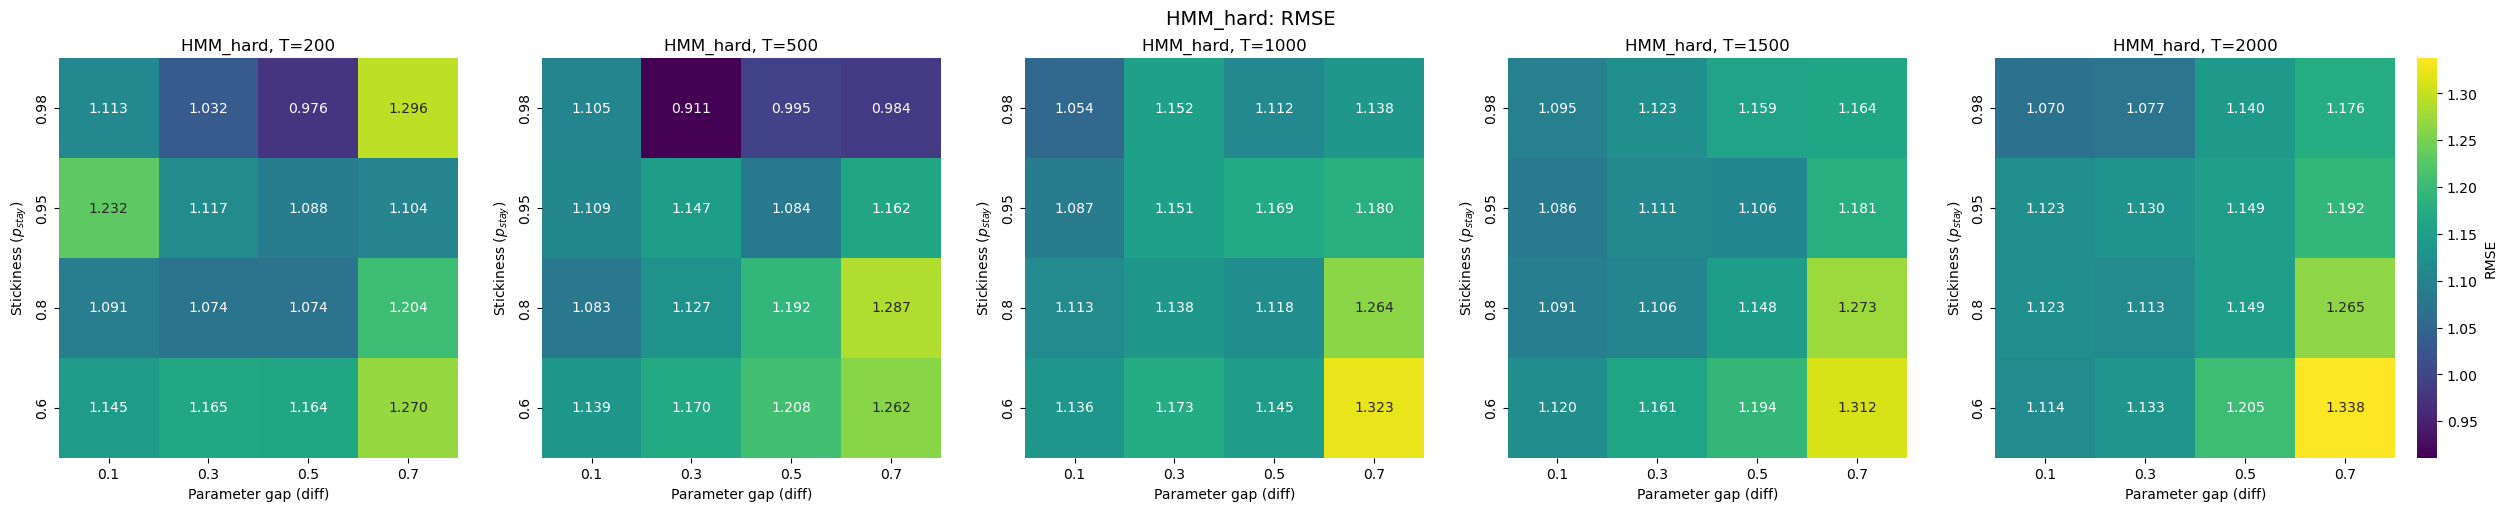

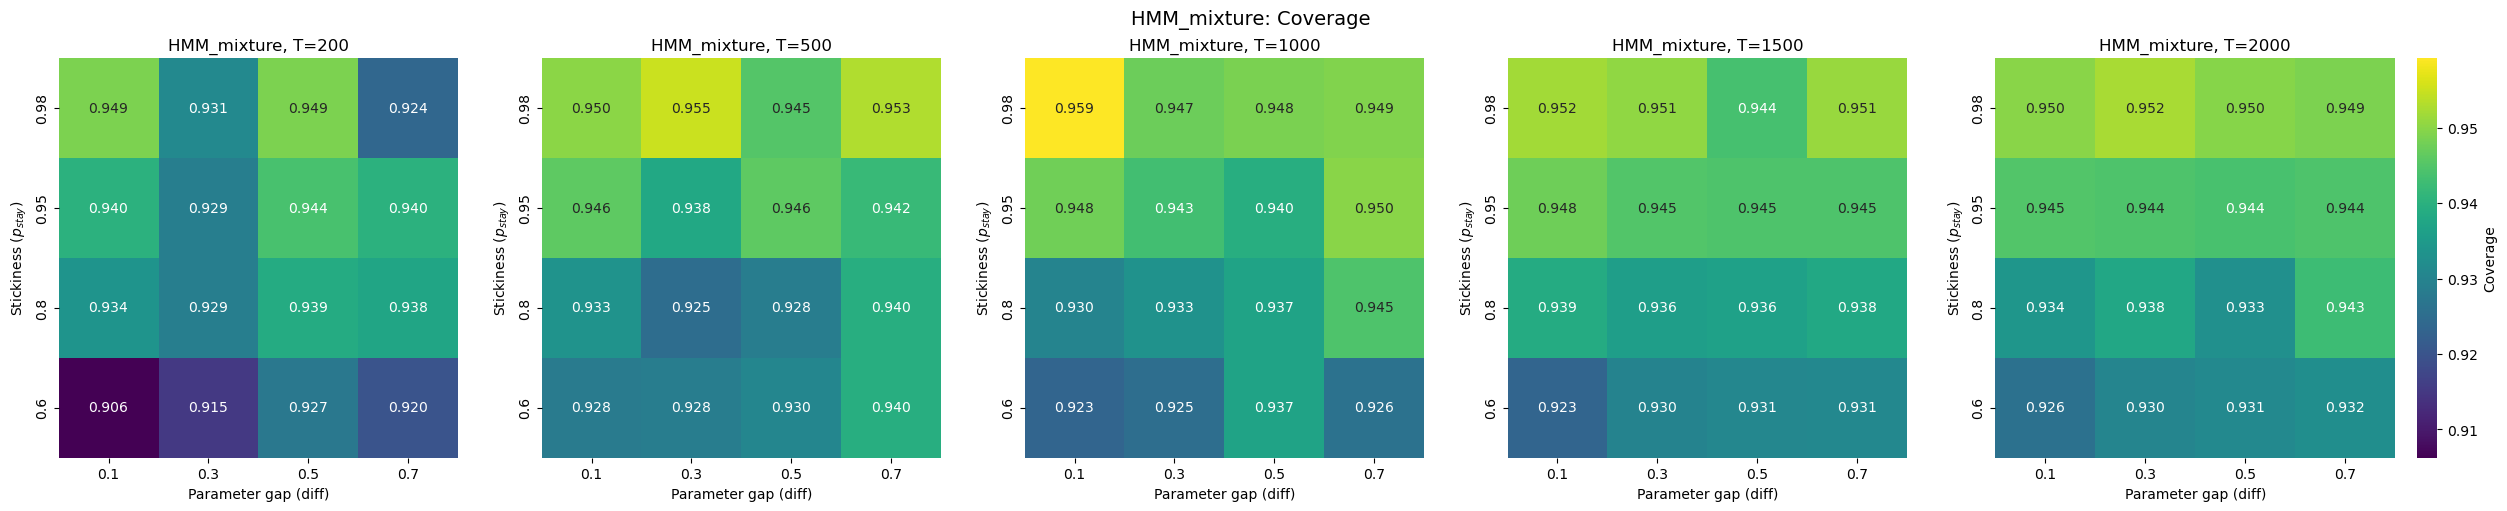

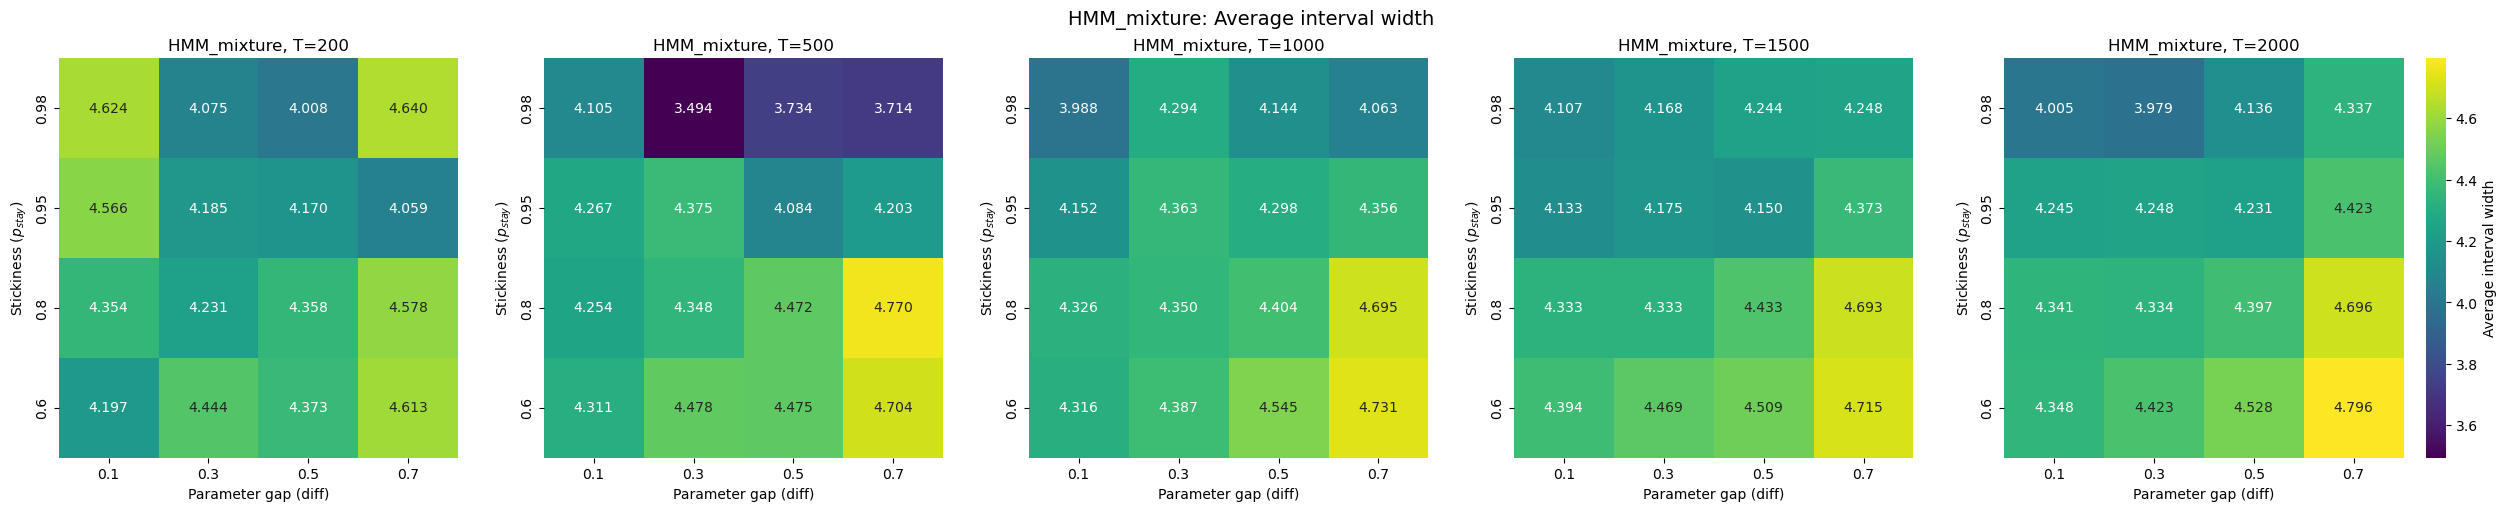

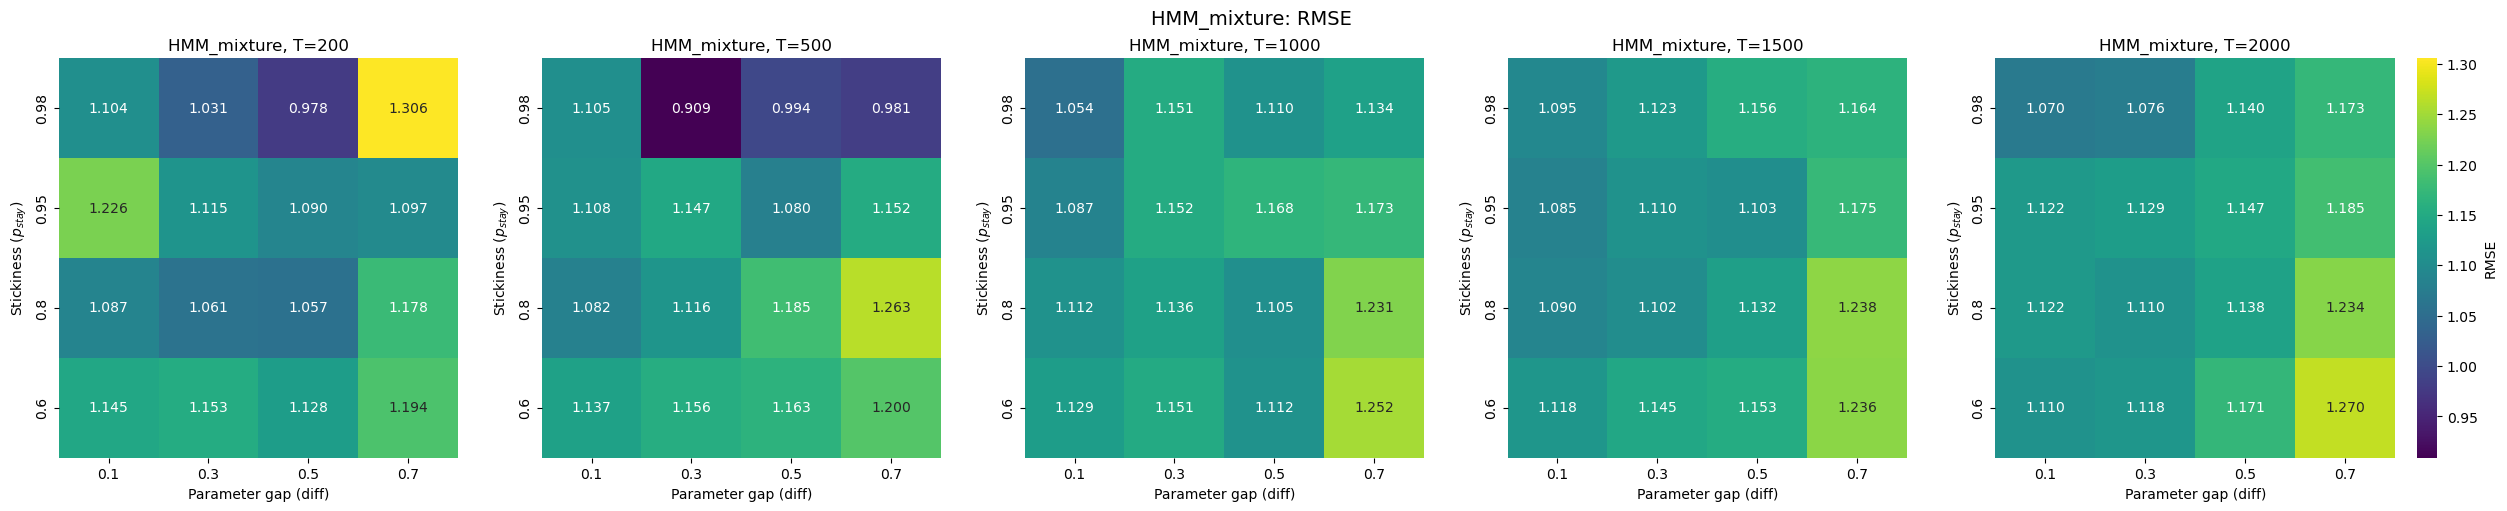

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

methods = ["AR1", "HMM_hard", "HMM_mixture"]
metrics = {
    "coverage_mean": "Coverage",
    "avg_width_mean": "Average interval width",
    "rmse_mean": "RMSE"
}

for method in methods:
    for metric, metric_label in metrics.items():
        plot_df = summary_df[summary_df["method"] == method].copy()

        T_vals_sorted = sorted(plot_df["T"].unique())
        n_panels = len(T_vals_sorted)

        fig, axes = plt.subplots(
            1, n_panels,
            figsize=(5 * n_panels, 5),
            constrained_layout=True
        )

        if n_panels == 1:
            axes = [axes]

        vmin = plot_df[metric].min()
        vmax = plot_df[metric].max()

        for ax, T in zip(axes, T_vals_sorted):
            sub = plot_df[plot_df["T"] == T].pivot(
                index="p_stay",
                columns="diff",
                values=metric
            ).sort_index(ascending=False)

            sns.heatmap(
                sub,
                ax=ax,
                cmap="viridis",
                vmin=vmin,
                vmax=vmax,
                annot=True,
                fmt=".3f",
                square=True,
                cbar=ax is axes[-1],
                cbar_kws={"label": metric_label} if ax is axes[-1] else None
            )

            ax.set_title(f"{method}, T={T}")
            ax.set_xlabel("Parameter gap (diff)")
            ax.set_ylabel("Stickiness ($p_{stay}$)")

        fig.suptitle(f"{method}: {metric_label}", fontsize=14)
        plt.show()


### Mer plots

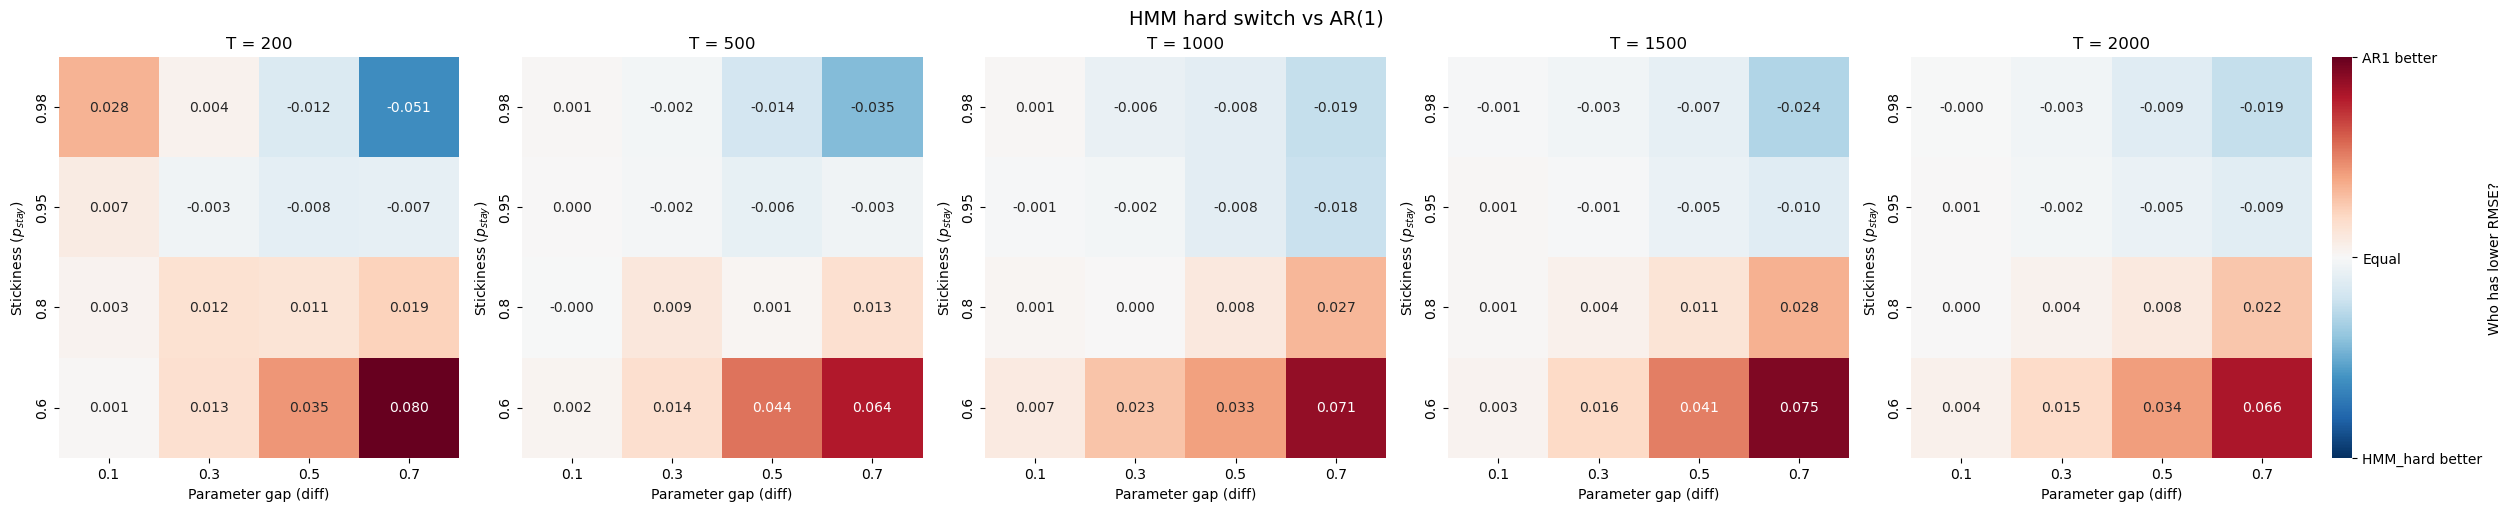

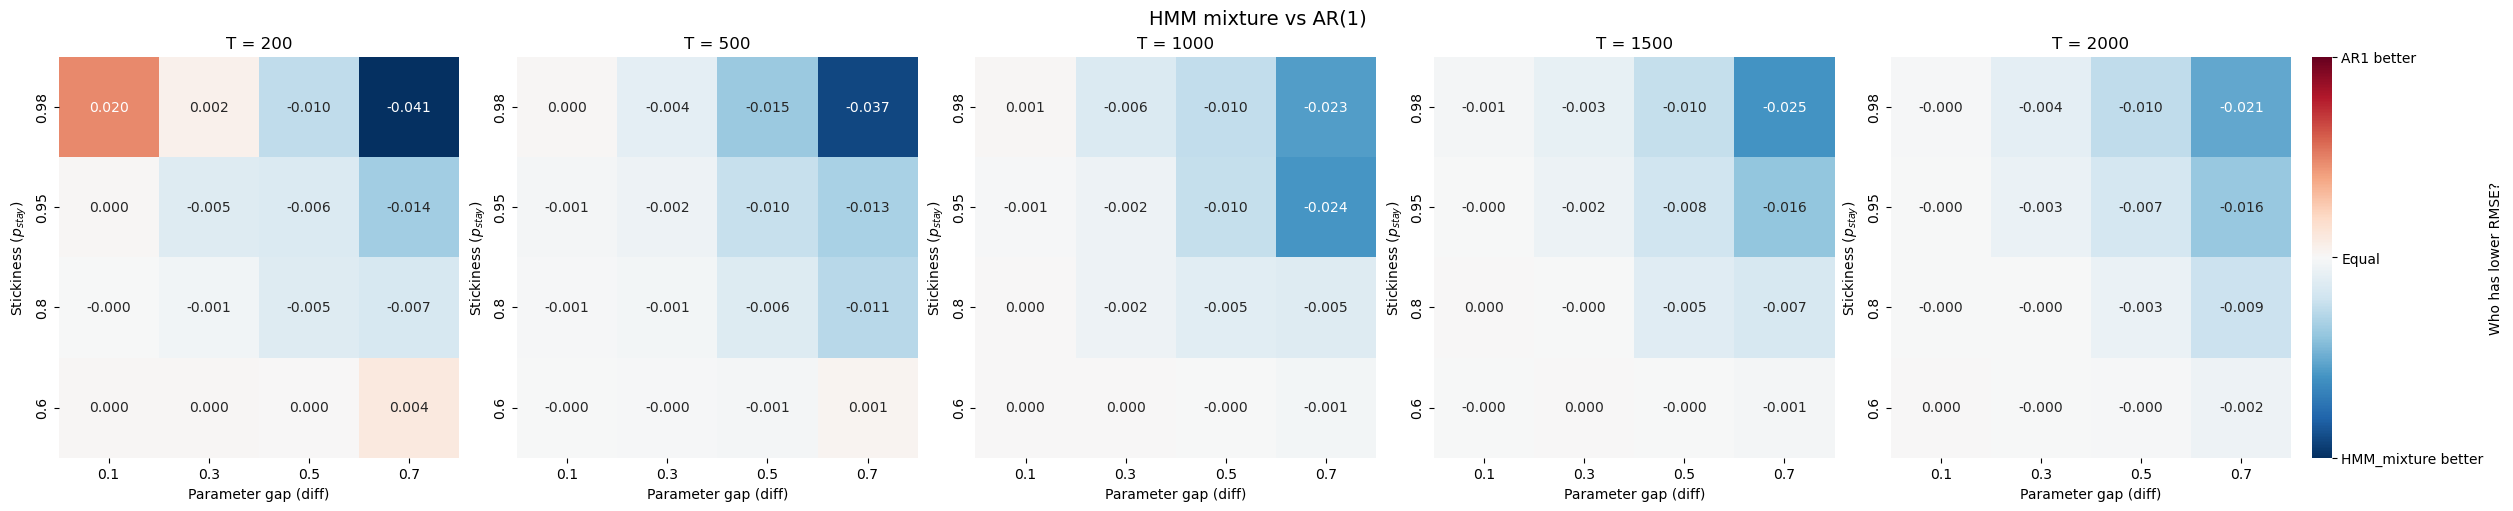

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

comparisons = [
    ("HMM_hard", "AR1", "HMM hard switch vs AR(1)"),
    ("HMM_mixture", "AR1", "HMM mixture vs AR(1)")
]

for method_a, method_b, title in comparisons:
    df_a = summary_df[summary_df["method"] == method_a][
        ["T", "diff", "p_stay", "rmse_mean"]
    ].rename(columns={"rmse_mean": "rmse_a"})

    df_b = summary_df[summary_df["method"] == method_b][
        ["T", "diff", "p_stay", "rmse_mean"]
    ].rename(columns={"rmse_mean": "rmse_b"})

    plot_df = df_a.merge(df_b, on=["T", "diff", "p_stay"])
    plot_df["rmse_diff"] = plot_df["rmse_a"] - plot_df["rmse_b"]

    T_vals_sorted = sorted(plot_df["T"].unique())
    n_panels = len(T_vals_sorted)

    fig, axes = plt.subplots(
        1, n_panels,
        figsize=(5 * n_panels, 5),
        constrained_layout=True
    )

    if n_panels == 1:
        axes = [axes]

    max_abs = np.nanmax(np.abs(plot_df["rmse_diff"]))

    for ax, T in zip(axes, T_vals_sorted):
        sub = plot_df[plot_df["T"] == T].pivot(
            index="p_stay",
            columns="diff",
            values="rmse_diff"
        ).sort_index(ascending=False)

        hm = sns.heatmap(
            sub,
            ax=ax,
            cmap="RdBu_r",
            vmin=-max_abs,
            vmax=max_abs,
            center=0,
            annot=True,
            fmt=".3f",
            square=True,
            cbar=ax is axes[-1],
            cbar_kws={"label": "Who has lower RMSE?"} if ax is axes[-1] else None
        )

        ax.set_title(f"T = {T}")
        ax.set_xlabel("Parameter gap (diff)")
        ax.set_ylabel("Stickiness ($p_{stay}$)")

        if ax is axes[-1]:
            cbar = hm.collections[0].colorbar
            cbar.set_ticks([-max_abs, 0, max_abs])
            cbar.set_ticklabels([f"{method_a} better", "Equal", f"{method_b} better"])

    fig.suptitle(title, fontsize=14)
    plt.show()


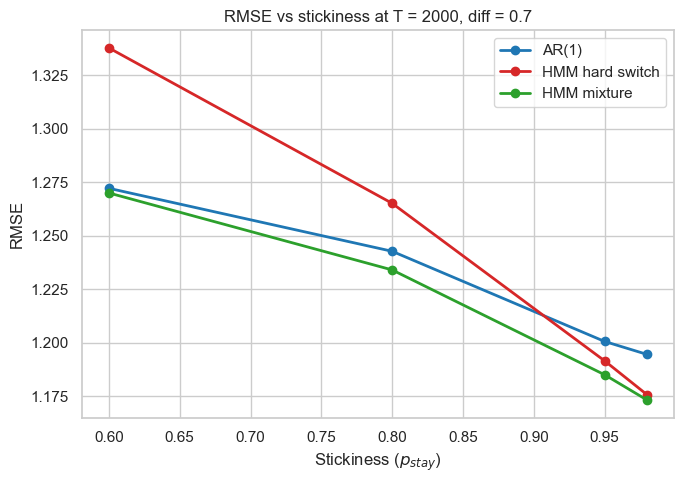

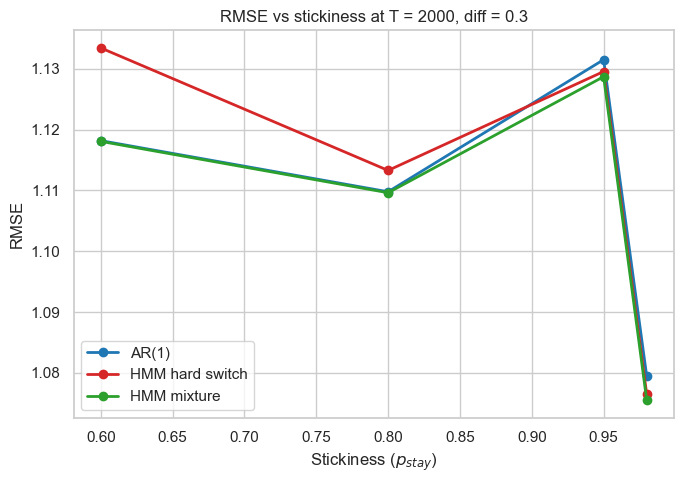

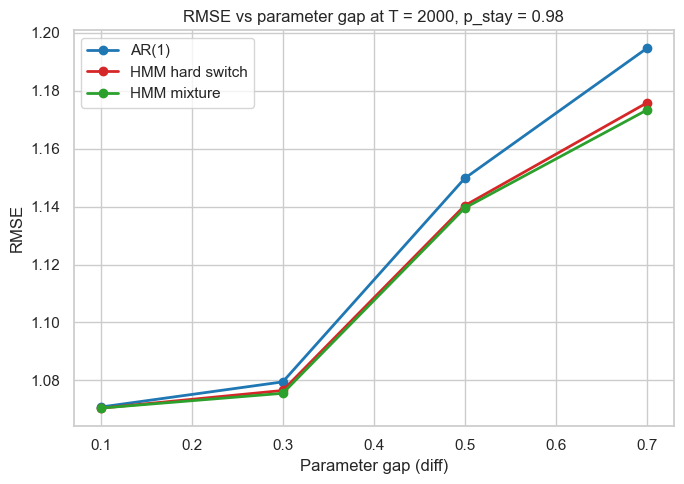

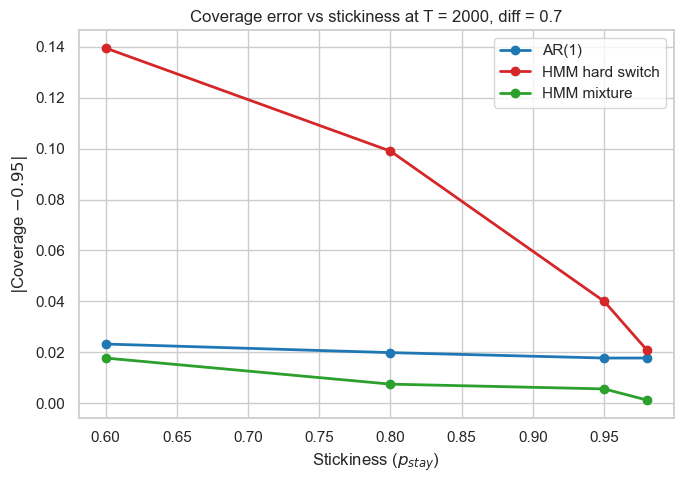

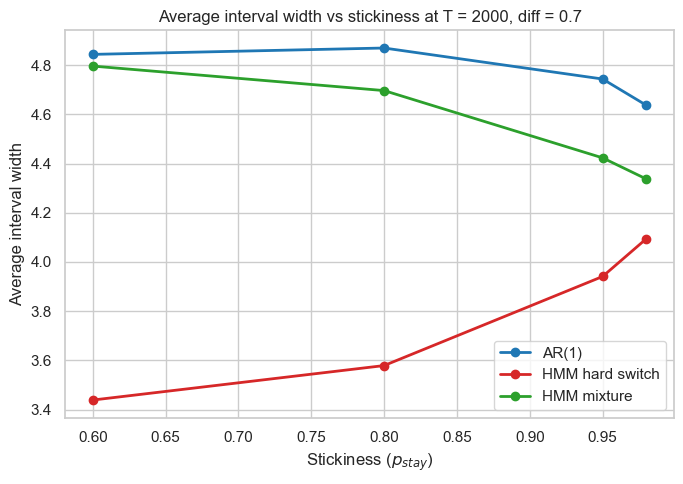

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plot_df = summary_df.copy()
plot_df["coverage_error"] = np.abs(plot_df["coverage_mean"] - 0.95)

method_labels = {
    "AR1": "AR(1)",
    "HMM_hard": "HMM hard switch",
    "HMM_mixture": "HMM mixture"
}

palette = {
    "AR1": "#1f77b4",
    "HMM_hard": "#d62728",
    "HMM_mixture": "#2ca02c"
}

# Figure 1: RMSE vs stickiness for T = 2000, high regime separation
fig, ax = plt.subplots(figsize=(7, 5))
sub = plot_df[(plot_df["T"] == 2000) & (plot_df["diff"] == 0.7)]

for method in ["AR1", "HMM_hard", "HMM_mixture"]:
    tmp = sub[sub["method"] == method].sort_values("p_stay")
    ax.plot(tmp["p_stay"], tmp["rmse_mean"], marker="o", linewidth=2,
            label=method_labels[method], color=palette[method])

ax.set_title("RMSE vs stickiness at T = 2000, diff = 0.7")
ax.set_xlabel("Stickiness ($p_{stay}$)")
ax.set_ylabel("RMSE")
ax.legend()
plt.tight_layout()
plt.show()


# Figure 2: RMSE vs stickiness for T = 2000, moderate regime separation
fig, ax = plt.subplots(figsize=(7, 5))
sub = plot_df[(plot_df["T"] == 2000) & (plot_df["diff"] == 0.3)]

for method in ["AR1", "HMM_hard", "HMM_mixture"]:
    tmp = sub[sub["method"] == method].sort_values("p_stay")
    ax.plot(tmp["p_stay"], tmp["rmse_mean"], marker="o", linewidth=2,
            label=method_labels[method], color=palette[method])

ax.set_title("RMSE vs stickiness at T = 2000, diff = 0.3")
ax.set_xlabel("Stickiness ($p_{stay}$)")
ax.set_ylabel("RMSE")
ax.legend()
plt.tight_layout()
plt.show()


# Figure 3: RMSE vs parameter gap for T = 2000, high stickiness
fig, ax = plt.subplots(figsize=(7, 5))
sub = plot_df[(plot_df["T"] == 2000) & (plot_df["p_stay"] == 0.98)]

for method in ["AR1", "HMM_hard", "HMM_mixture"]:
    tmp = sub[sub["method"] == method].sort_values("diff")
    ax.plot(tmp["diff"], tmp["rmse_mean"], marker="o", linewidth=2,
            label=method_labels[method], color=palette[method])

ax.set_title("RMSE vs parameter gap at T = 2000, p_stay = 0.98")
ax.set_xlabel("Parameter gap (diff)")
ax.set_ylabel("RMSE")
ax.legend()
plt.tight_layout()
plt.show()


# Figure 4: Coverage error vs stickiness for T = 2000, high regime separation
fig, ax = plt.subplots(figsize=(7, 5))
sub = plot_df[(plot_df["T"] == 2000) & (plot_df["diff"] == 0.7)]

for method in ["AR1", "HMM_hard", "HMM_mixture"]:
    tmp = sub[sub["method"] == method].sort_values("p_stay")
    ax.plot(tmp["p_stay"], tmp["coverage_error"], marker="o", linewidth=2,
            label=method_labels[method], color=palette[method])

ax.set_title("Coverage error vs stickiness at T = 2000, diff = 0.7")
ax.set_xlabel("Stickiness ($p_{stay}$)")
ax.set_ylabel(r"$|$Coverage $- 0.95|$")
ax.legend()
plt.tight_layout()
plt.show()


# Figure 5: Average interval width vs stickiness for T = 2000, high regime separation
fig, ax = plt.subplots(figsize=(7, 5))
sub = plot_df[(plot_df["T"] == 2000) & (plot_df["diff"] == 0.7)]

for method in ["AR1", "HMM_hard", "HMM_mixture"]:
    tmp = sub[sub["method"] == method].sort_values("p_stay")
    ax.plot(tmp["p_stay"], tmp["avg_width_mean"], marker="o", linewidth=2,
            label=method_labels[method], color=palette[method])

ax.set_title("Average interval width vs stickiness at T = 2000, diff = 0.7")
ax.set_xlabel("Stickiness ($p_{stay}$)")
ax.set_ylabel("Average interval width")
ax.legend()
plt.tight_layout()
plt.show()


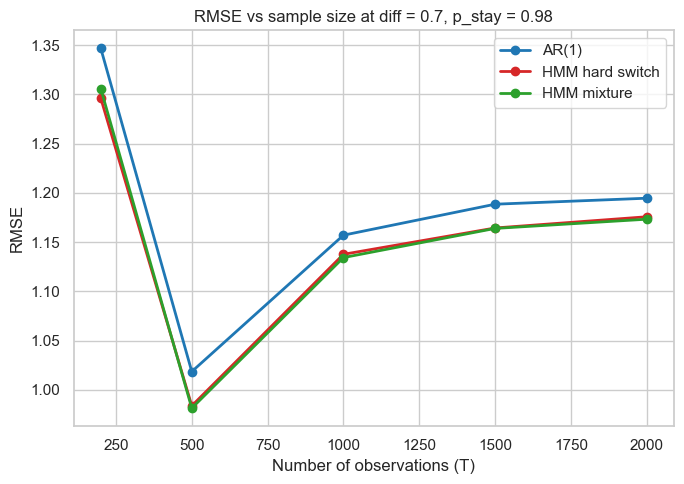

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

sub = plot_df[(plot_df["diff"] == 0.7) & (plot_df["p_stay"] == 0.98)]

for method in ["AR1", "HMM_hard", "HMM_mixture"]:
    tmp = sub[sub["method"] == method].sort_values("T")
    ax.plot(
        tmp["T"],
        tmp["rmse_mean"],
        marker="o",
        linewidth=2,
        label=method_labels[method],
        color=palette[method]
    )

ax.set_title("RMSE vs sample size at diff = 0.7, p_stay = 0.98")
ax.set_xlabel("Number of observations (T)")
ax.set_ylabel("RMSE")
ax.legend()
plt.tight_layout()
plt.show()
